# MWE 15 - External `pnextract` / `pnflow` benchmark against `voids`

This notebook compares `voids` against a committed reference dataset produced earlier with the
Imperial College `pnextract` + `pnflow` workflow. The reference data now lives under
`examples/data/external_pnflow_benchmark/`, so this notebook does not invoke `pnextract` or
`pnflow` and remains runnable even if those binaries are unavailable in the future.

The committed benchmark bundle includes:

- the exact binary input volumes used for the benchmark
- `pnflow` report files (`*_pnflow.prt`, `*_upscaled.tsv`)
- extracted-network files (`*_node*.dat`, `*_link*.dat`) for later inspection

Scientific scope and caveats:
- this is an end-to-end workflow comparison, not a solver-only cross-check
- any mismatch reflects both extraction differences and constitutive-model differences
- the `voids` side is evaluated in two modes:
  - import the saved `pnextract` CNM network and solve it with `voids`
  - re-extract the saved binary volume with `snow2` and solve that network with `voids`
- the external side uses previously saved `pnextract` geometry plus `pnflow`'s internal
  single-phase model
- the committed input volumes make this benchmark stable against future changes in the synthetic
  generator implementation
- we keep `mu = constant` here on purpose because the checked `pnflow` code path uses scalar fluid
  viscosities rather than a thermodynamic `mu(P, T)` coupling

In [1]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from voids.image import extract_spanning_pore_network
from voids.io import load_pnflow_cnm
from voids.paths import data_path, project_root
from voids.physics.petrophysics import absolute_porosity, effective_porosity
from voids.physics.singlephase import (
    FluidSinglePhase,
    PressureBC,
    SinglePhaseOptions,
    solve,
)


def _require_match(pattern: str, text: str, *, label: str) -> re.Match[str]:
    match = re.search(pattern, text, flags=re.MULTILINE)
    if match is None:
        raise ValueError(f"Could not parse {label!r}")
    return match


def _parse_upscaled_metrics(path: Path, *, prefix: str) -> dict[str, float]:
    text = path.read_text()
    permeability = float(
        _require_match(
            rf"{re.escape(prefix)}_permeability:\s*([0-9.eE+-]+);",
            text,
            label=f"{prefix}_permeability",
        ).group(1)
    )
    porosity = float(
        _require_match(
            rf"{re.escape(prefix)}_porosity:\s*([0-9.eE+-]+);",
            text,
            label=f"{prefix}_porosity",
        ).group(1)
    )
    formation_factor = float(
        _require_match(
            rf"{re.escape(prefix)}_formationfactor:\s*([0-9.eE+-]+);",
            text,
            label=f"{prefix}_formationfactor",
        ).group(1)
    )
    return {
        "k_pnflow": permeability,
        "phi_pnflow": porosity,
        "formation_factor_pnflow": formation_factor,
    }


def _parse_pnflow_prt(path: Path) -> dict[str, float | int]:
    text = path.read_text()
    int_patterns = {
        "pnflow_n_pores": r"Number of pores:\s+([0-9]+)",
        "pnflow_n_throats": r"Number of throats:\s+([0-9]+)",
        "pnflow_n_inlet_connections": r"Number of inlet connections:\s+([0-9]+)",
        "pnflow_n_outlet_connections": r"Number of outlet connections:\s+([0-9]+)",
        "pnflow_n_isolated_elements": r"Number of isolated elements:\s+([0-9]+)",
    }
    float_patterns = {
        "phi_pnflow_prt": r"Total porosity:\s+([0-9.eE+-]+)",
        "k_pnflow_prt": r"Absolute permeability:\s+([0-9.eE+-]+)",
    }
    parsed: dict[str, float | int] = {}
    for key, pattern in int_patterns.items():
        value = _require_match(pattern, text, label=key).group(1)
        parsed[key] = int(value)
    for key, pattern in float_patterns.items():
        value = _require_match(pattern, text, label=key).group(1)
        parsed[key] = float(value)
    return parsed


def _load_reference_case(
    reference_root: Path, row: pd.Series
) -> tuple[np.ndarray, dict[str, object]]:
    case = str(row["case"])
    volume = np.load(reference_root / str(row["volume_file"]))
    prt_path = reference_root / str(row["pnflow_prt_file"])
    upscaled_path = reference_root / str(row["pnflow_upscaled_file"])
    metrics: dict[str, object] = {
        **_parse_upscaled_metrics(upscaled_path, prefix=case),
        **_parse_pnflow_prt(prt_path),
        "reference_case_dir": str((reference_root / case).relative_to(project_root())),
    }
    return np.asarray(volume, dtype=bool), metrics


def _run_voids_from_volume_case(
    volume: np.ndarray,
    *,
    voxel_size: float,
    flow_axis: str,
    fluid: FluidSinglePhase,
    options: SinglePhaseOptions,
) -> dict[str, float | int]:
    extract = extract_spanning_pore_network(
        volume.astype(int),
        voxel_size=voxel_size,
        flow_axis=flow_axis,
        provenance_notes={"benchmark_kind": "external_pnflow_reference"},
    )
    bc = PressureBC(
        f"inlet_{flow_axis}min",
        f"outlet_{flow_axis}max",
        pin=2.0e5,
        pout=0.0,
    )
    result = solve(
        extract.net,
        fluid=fluid,
        bc=bc,
        axis=flow_axis,
        options=options,
    )
    return {
        "phi_image": float(np.asarray(volume, dtype=bool).mean()),
        "phi_abs_porespy_voids": float(absolute_porosity(extract.net)),
        "phi_eff_porespy_voids": float(effective_porosity(extract.net, axis=flow_axis)),
        "Np_porespy_voids": int(extract.net.Np),
        "Nt_porespy_voids": int(extract.net.Nt),
        "k_porespy_voids": float(result.permeability[flow_axis]),
        "Q_porespy_voids": float(result.total_flow_rate),
    }


def _run_voids_on_imported_cnm_case(
    prefix: Path,
    *,
    flow_axis: str,
    fluid: FluidSinglePhase,
    options: SinglePhaseOptions,
) -> dict[str, float | int]:
    imported = load_pnflow_cnm(prefix)
    bc = PressureBC(
        f"inlet_{flow_axis}min",
        f"outlet_{flow_axis}max",
        pin=2.0e5,
        pout=0.0,
    )
    result = solve(
        imported.net,
        fluid=fluid,
        bc=bc,
        axis=flow_axis,
        options=options,
    )
    return {
        "phi_abs_imported_voids": float(absolute_porosity(imported.net)),
        "phi_eff_imported_voids": float(
            effective_porosity(imported.net, axis=flow_axis)
        ),
        "Np_imported_physical": int(imported.n_physical_pores),
        "Np_imported_total": int(imported.net.Np),
        "Np_imported_boundary_mirror": int(imported.n_boundary_mirror_pores),
        "Nt_imported_voids": int(imported.net.Nt),
        "k_imported_voids": float(result.permeability[flow_axis]),
        "Q_imported_voids": float(result.total_flow_rate),
    }


def _make_permeability_comparison_figure(
    summary_frame: pd.DataFrame,
    *,
    output_path: Path,
) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    kmin = float(
        min(
            summary_frame["k_imported_voids"].min(),
            summary_frame["k_porespy_voids"].min(),
            summary_frame["k_pnflow"].min(),
        )
    )
    kmax = float(
        max(
            summary_frame["k_imported_voids"].max(),
            summary_frame["k_porespy_voids"].max(),
            summary_frame["k_pnflow"].max(),
        )
    )
    pad = 0.05 * max(kmax - kmin, 1.0e-30)

    axes[0].scatter(
        summary_frame["k_pnflow"],
        summary_frame["k_imported_voids"],
        s=65,
        color="tab:green",
        label="voids on imported pnextract CNM",
    )
    axes[0].scatter(
        summary_frame["k_pnflow"],
        summary_frame["k_porespy_voids"],
        s=65,
        color="tab:blue",
        label="voids on PoreSpy extraction",
    )
    axes[0].plot(
        [kmin - pad, kmax + pad],
        [kmin - pad, kmax + pad],
        color="black",
        lw=1.2,
        linestyle="--",
    )
    for row in summary_frame.itertuples(index=False):
        axes[0].annotate(
            row.case,
            (row.k_pnflow, row.k_imported_voids),
            textcoords="offset points",
            xytext=(5, 4),
            fontsize=8,
        )
    axes[0].set_xlabel("pnflow permeability [m$^2$]")
    axes[0].set_ylabel("voids permeability [m$^2$]")
    axes[0].set_title("Permeability scatter")
    axes[0].legend()

    x = np.arange(len(summary_frame))
    width = 0.36
    axes[1].bar(
        x - 0.5 * width,
        100.0 * summary_frame["k_rel_diff_imported"],
        width=width,
        color="tab:green",
        label="imported CNM",
    )
    axes[1].bar(
        x + 0.5 * width,
        100.0 * summary_frame["k_rel_diff_porespy"],
        width=width,
        color="tab:orange",
        label="PoreSpy extraction",
    )
    axes[1].set_xticks(x, summary_frame["case"], rotation=25)
    axes[1].set_xlabel("case")
    axes[1].set_ylabel("relative difference [%]")
    axes[1].set_title("Per-case permeability mismatch")
    axes[1].legend()

    fig.suptitle("External pnflow benchmark", fontsize=13)
    plt.tight_layout()
    fig.savefig(output_path, dpi=160, bbox_inches="tight")
    plt.show()


def _make_porosity_trend_figure(
    summary_frame: pd.DataFrame,
    *,
    output_path: Path,
) -> None:
    plot_df = summary_frame.sort_values(["phi_image", "blobiness"]).copy()
    fig, ax = plt.subplots(figsize=(7.5, 4.8))

    ax.semilogy(
        plot_df["phi_image"],
        plot_df["k_pnflow"],
        marker="o",
        lw=1.5,
        label="pnflow",
    )
    ax.semilogy(
        plot_df["phi_image"],
        plot_df["k_imported_voids"],
        marker="^",
        lw=1.5,
        label="voids on imported pnextract CNM",
    )
    ax.semilogy(
        plot_df["phi_image"],
        plot_df["k_porespy_voids"],
        marker="s",
        lw=1.5,
        label="voids on PoreSpy extraction",
    )
    ax.set_xlabel("image porosity [-]")
    ax.set_ylabel("permeability [m$^2$]")
    ax.set_title("Permeability trend with porosity")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()

    plt.tight_layout()
    fig.savefig(output_path, dpi=160, bbox_inches="tight")
    plt.show()


examples_data = data_path()
reference_root = examples_data / "external_pnflow_benchmark"
manifest_path = reference_root / "manifest.csv"
report_dir = project_root() / "docs" / "assets" / "verification"
report_dir.mkdir(parents=True, exist_ok=True)
report_csv = report_dir / "pnflow_5_case_results.csv"
comparison_figure_path = report_dir / "pnflow_permeability_scatter_and_error.png"
porosity_figure_path = report_dir / "pnflow_porosity_vs_permeability.png"

if not manifest_path.exists():
    raise FileNotFoundError(
        "Committed reference data not found. Expected " f"{manifest_path} to exist."
    )

fluid = FluidSinglePhase(viscosity=1.0e-3)
options = SinglePhaseOptions(
    conductance_model="valvatne_blunt",
    solver="direct",
)
manifest_df = pd.read_csv(manifest_path)

## Reference dataset provenance

The table below is the committed benchmark manifest. The notebook loads the exact saved volumes
and previously generated `pnflow` reports from `examples/data/external_pnflow_benchmark/`.

In [2]:
manifest_df

,case,shape,porosity_target,blobiness,seed_start,seed_used,flow_axis,voxel_size_m,volume_file,pnflow_prt_file,pnflow_upscaled_file
0,phi032_b14,32x32x32,0.32,1.4,401,401,x,0.000002,phi032_b14/void_volume.npy,phi032_b14/phi032_b14_pnflow.prt,phi032_b14/phi032_b14_upscaled.tsv
1,phi035_b16,32x32x32,0.35,1.6,501,501,x,0.000002,phi035_b16/void_volume.npy,phi035_b16/phi035_b16_pnflow.prt,phi035_b16/phi035_b16_upscaled.tsv
2,phi038_b18,32x32x32,0.38,1.8,601,601,x,0.000002,phi038_b18/void_volume.npy,phi038_b18/phi038_b18_pnflow.prt,phi038_b18/phi038_b18_upscaled.tsv
3,phi040_b18,32x32x32,0.40,1.8,901,901,x,0.000002,phi040_b18/void_volume.npy,phi040_b18/phi040_b18_pnflow.prt,phi040_b18/phi040_b18_upscaled.tsv
4,phi041_b20,32x32x32,0.41,2.0,701,701,x,0.000002,phi041_b20/void_volume.npy,phi041_b20/phi041_b20_pnflow.prt,phi041_b20/phi041_b20_upscaled.tsv


## Representative benchmark input

The committed input volumes are binary segmented images (`True` = void) that were used in the
original external `pnextract` / `pnflow` run.

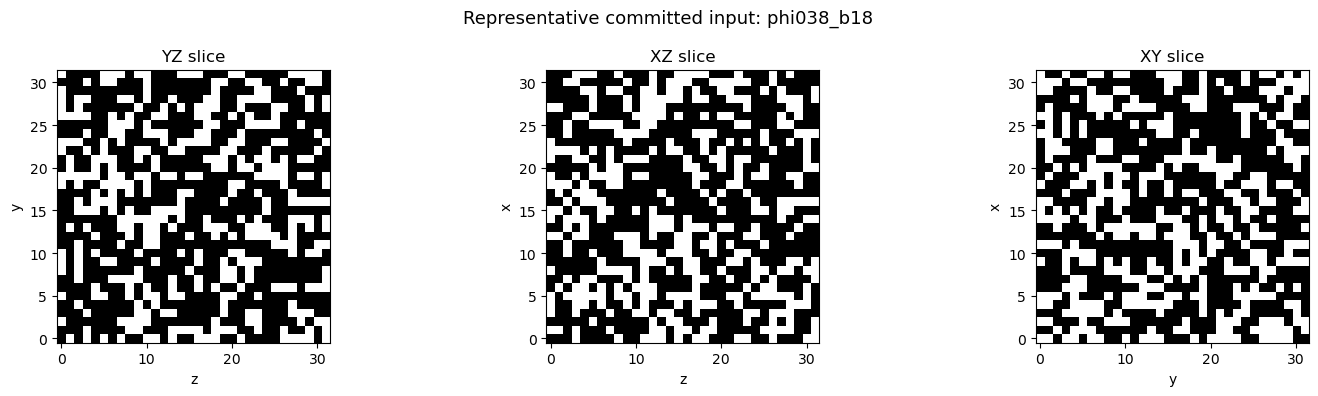

shape = (32, 32, 32)
void fraction = 0.3800048828125


In [3]:
representative_row = manifest_df.loc[manifest_df["case"] == "phi038_b18"].iloc[0]
representative_volume = np.load(
    reference_root / representative_row["volume_file"]
).astype(bool)
mid = representative_volume.shape[0] // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(representative_volume[mid, :, :], cmap="gray", origin="lower")
axes[0].set_title("YZ slice")
axes[0].set_xlabel("z")
axes[0].set_ylabel("y")

axes[1].imshow(representative_volume[:, mid, :], cmap="gray", origin="lower")
axes[1].set_title("XZ slice")
axes[1].set_xlabel("z")
axes[1].set_ylabel("x")

axes[2].imshow(representative_volume[:, :, mid], cmap="gray", origin="lower")
axes[2].set_title("XY slice")
axes[2].set_xlabel("y")
axes[2].set_ylabel("x")

fig.suptitle(
    f"Representative committed input: {representative_row['case']}", fontsize=13
)
plt.tight_layout()
plt.show()

print("shape =", representative_volume.shape)
print("void fraction =", float(representative_volume.mean()))

## Run `voids` against the committed external references

For each case, the notebook loads the saved external outputs and then evaluates two `voids`
pathways:

- imported CNM: reuse the saved `pnextract` network and compare the `voids` single-phase solve
  directly against `pnflow`
- image extraction: re-extract the saved binary volume with the current `voids` `snow2` workflow
  and compare that full path against `pnflow`

This split helps identify whether a mismatch is dominated by extraction or by the single-phase
solver/geometry interpretation on the same network.

In [4]:
rows: list[dict[str, object]] = []

for row in manifest_df.itertuples(index=False):
    row_series = pd.Series(row._asdict())
    volume, pnflow_metrics = _load_reference_case(reference_root, row_series)
    case_root = reference_root / str(row_series["case"])
    imported_metrics = _run_voids_on_imported_cnm_case(
        case_root / str(row_series["case"]),
        flow_axis=str(row_series["flow_axis"]),
        fluid=fluid,
        options=options,
    )
    porespy_metrics = _run_voids_from_volume_case(
        volume,
        voxel_size=float(row_series["voxel_size_m"]),
        flow_axis=str(row_series["flow_axis"]),
        fluid=fluid,
        options=options,
    )
    rows.append(
        {
            **row._asdict(),
            **pnflow_metrics,
            **imported_metrics,
            **porespy_metrics,
        }
    )

summary_df = pd.DataFrame(rows)
summary_df["k_ratio_imported_to_pnflow"] = (
    summary_df["k_imported_voids"] / summary_df["k_pnflow"]
)
summary_df["k_ratio_porespy_to_pnflow"] = (
    summary_df["k_porespy_voids"] / summary_df["k_pnflow"]
)
summary_df["k_rel_diff_imported"] = np.abs(
    summary_df["k_imported_voids"] - summary_df["k_pnflow"]
) / np.maximum(
    np.maximum(np.abs(summary_df["k_imported_voids"]), np.abs(summary_df["k_pnflow"])),
    1.0e-30,
)
summary_df["k_rel_diff_porespy"] = np.abs(
    summary_df["k_porespy_voids"] - summary_df["k_pnflow"]
) / np.maximum(
    np.maximum(np.abs(summary_df["k_porespy_voids"]), np.abs(summary_df["k_pnflow"])),
    1.0e-30,
)
summary_df["phi_abs_diff_imported"] = (
    summary_df["phi_abs_imported_voids"] - summary_df["phi_pnflow"]
)
summary_df["phi_abs_diff_porespy"] = (
    summary_df["phi_abs_porespy_voids"] - summary_df["phi_pnflow"]
)
summary_df["np_rel_diff_imported"] = np.abs(
    summary_df["Np_imported_physical"] - summary_df["pnflow_n_pores"]
) / np.maximum(summary_df["pnflow_n_pores"], 1.0)
summary_df["np_rel_diff_porespy"] = np.abs(
    summary_df["Np_porespy_voids"] - summary_df["pnflow_n_pores"]
) / np.maximum(summary_df["pnflow_n_pores"], 1.0)
summary_df["nt_rel_diff_imported"] = np.abs(
    summary_df["Nt_imported_voids"] - summary_df["pnflow_n_throats"]
) / np.maximum(summary_df["pnflow_n_throats"], 1.0)
summary_df["nt_rel_diff_porespy"] = np.abs(
    summary_df["Nt_porespy_voids"] - summary_df["pnflow_n_throats"]
) / np.maximum(summary_df["pnflow_n_throats"], 1.0)

display_columns = [
    "case",
    "seed_used",
    "porosity_target",
    "blobiness",
    "phi_image",
    "phi_abs_imported_voids",
    "phi_abs_porespy_voids",
    "phi_pnflow",
    "Np_imported_physical",
    "Np_porespy_voids",
    "pnflow_n_pores",
    "Nt_imported_voids",
    "Nt_porespy_voids",
    "pnflow_n_throats",
    "k_imported_voids",
    "k_porespy_voids",
    "k_pnflow",
    "k_rel_diff_imported",
    "k_rel_diff_porespy",
]
summary_df.loc[:, display_columns]

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


,case,seed_used,porosity_target,blobiness,phi_image,phi_abs_imported_voids,phi_abs_porespy_voids,phi_pnflow,Np_imported_physical,Np_porespy_voids,pnflow_n_pores,Nt_imported_voids,Nt_porespy_voids,pnflow_n_throats,k_imported_voids,k_porespy_voids,k_pnflow,k_rel_diff_imported,k_rel_diff_porespy
0,phi032_b14,401,0.32,1.4,0.320007,0.276611,0.320190,0.275787,80,53,80,202,150,202,9.748383e-15,6.096766e-15,9.751930e-15,0.000364,0.374814
1,phi035_b16,501,0.35,1.6,0.350006,0.297089,0.349762,0.295502,71,26,71,198,79,198,1.116500e-14,1.702232e-14,1.331850e-14,0.161692,0.217586
2,phi038_b18,601,0.38,1.8,0.380005,0.322083,0.380005,0.316315,64,36,64,180,106,180,1.120140e-14,2.091703e-14,1.199270e-14,0.065982,0.426654
3,phi040_b18,901,0.40,1.8,0.399994,0.346832,0.399994,0.343414,83,45,83,280,134,280,1.457190e-14,2.033442e-14,1.575700e-14,0.075211,0.225107
4,phi041_b20,701,0.41,2.0,0.410004,0.354492,0.410004,0.354004,72,37,72,247,106,247,1.355238e-14,3.925603e-14,1.436830e-14,0.056786,0.633985


## Save derived comparison artifacts

The committed external reference data under `examples/data/` are treated as inputs. The CSV and
figures written here remain derived benchmark reports for documentation and review.

In [5]:
summary_df.to_csv(report_csv, index=False)
print("Saved:", report_csv)

Saved: /Users/dtvolpatto/Work/voids/docs/assets/verification/pnflow_5_case_results.csv


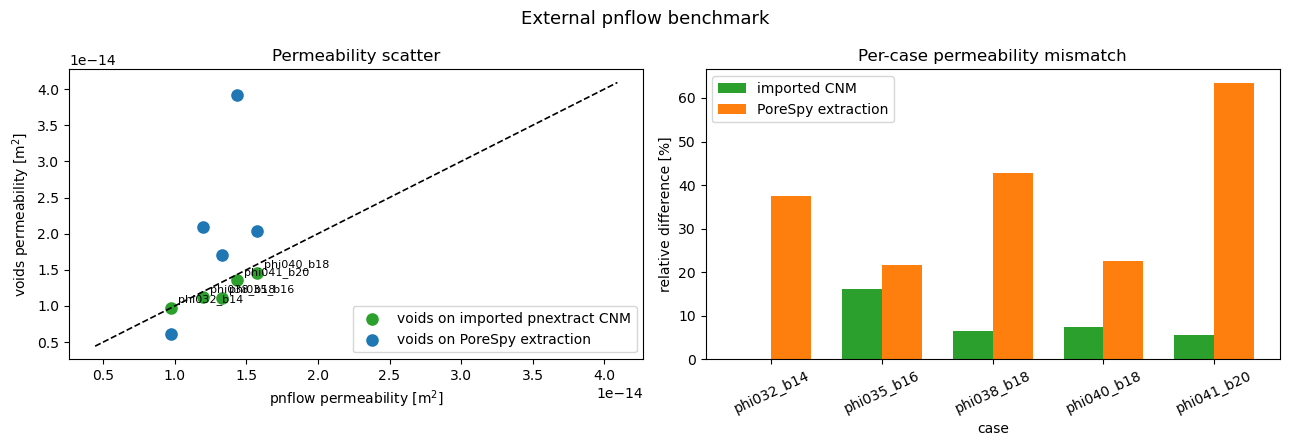

Saved: /Users/dtvolpatto/Work/voids/docs/assets/verification/pnflow_permeability_scatter_and_error.png


In [6]:
_make_permeability_comparison_figure(
    summary_df,
    output_path=comparison_figure_path,
)
print("Saved:", comparison_figure_path)

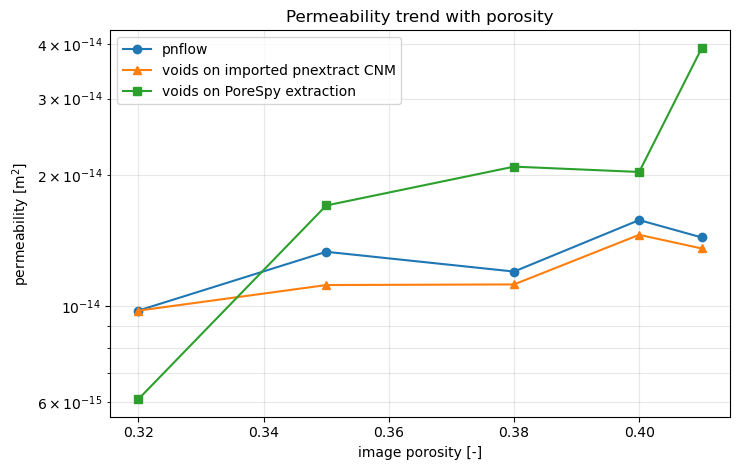

Saved: /Users/dtvolpatto/Work/voids/docs/assets/verification/pnflow_porosity_vs_permeability.png


In [7]:
_make_porosity_trend_figure(
    summary_df,
    output_path=porosity_figure_path,
)
print("Saved:", porosity_figure_path)

## Interpretation

The permeability comparison is the main benchmark output. The porosity and network-size columns
help diagnose whether a mismatch comes primarily from extraction topology, pore/throat geometry,
or the transport model itself.

Points to keep in mind when interpreting the numbers:
- `pnflow` reports porosity after its own extracted-network construction, not the binary-image
  void fraction
- imported-CNM and PoreSpy-extracted `voids` porosities are not identical diagnostics:
  the imported CNM includes the saved `pnextract` conduit volumes, while the PoreSpy path uses
  the current `voids` extraction and pruning workflow
- if imported-CNM permeability is much closer to `pnflow` than the PoreSpy path, the dominant
  remaining mismatch is likely extraction rather than the single-phase solver itself
- a close permeability match on the imported CNM is encouraging, but it still does not prove full
  geometric equivalence between implementations
- a large mismatch is not automatically a bug in `voids`; it may reflect different extraction and
  conductance assumptions in the two workflows